In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
power = pd.read_csv("data/power.csv")
power["t"] = pd.to_datetime(power["t"], unit="s")
power = power.set_index("t")
power.head()

,value
t,
2026-10-03 17:54:19.166879892,251.476974
2026-10-03 17:54:19.290238857,243.439469
2026-10-03 17:54:19.395206928,252.387084
2026-10-03 17:54:19.500396013,255.623387
2026-10-03 17:54:19.603703976,250.526138


In [15]:
power.describe()

,value
count,5622.000000
mean,273.492831
std,67.600152
min,-50.000000
25%,225.326670
50%,290.913359
75%,329.020249
max,377.724566


In [16]:
def load(name):
    df = pd.read_csv(f"data/{name}.csv")
    df["t"] = pd.to_datetime(df["t"], unit="s")
    return df.set_index("t")

power = load("power")
hr = load("hr")
cadence = load("cadence")
speed = load("speed")
gps = load("gps")

for name, df in [("power", power), ("hr", hr), ("cadence", cadence), ("speed", speed), ("gps", gps)]:
    print(name, len(df))

power 5622
hr 585
cadence 585
speed 585
gps 585


In [17]:
power_raw = power.copy()
hr_raw = hr.copy()

In [18]:
n = len(power)
power = power[power["value"] >= 0]
print("power removed:", n - len(power))

n = len(hr)
hr = hr[hr["value"] <= 220]
print("hr removed:", n - len(hr))

power removed: 49
hr removed: 3


In [19]:
print("cadence missing:", cadence["value"].isna().sum())

n = len(speed)
speed = speed[speed["value"] > 0]
print("speed removed:", n - len(speed))

cadence missing: 5
speed removed: 6


In [20]:
median_lat = gps["lat"].rolling(5, center=True, min_periods=1).median()
jump_m = (gps["lat"] - median_lat).abs() * 111000
n = len(gps)
gps = gps[jump_m < 50]
print("gps removed:", n - len(gps))

gps removed: 6


In [23]:
df = pd.concat({
    "power": power["value"].resample("1s").mean(),
    "hr": hr["value"].resample("1s").mean(),
    "cadence": cadence["value"].resample("1s").mean(),
    "speed": speed["value"].resample("1s").mean(),
    "lat": gps["lat"].resample("1s").mean(),
    "lon": gps["lon"].resample("1s").mean(),
}, axis=1)

print("missing before:\n", df.isna().sum())
df = df.interpolate(limit=5)
df = df.dropna()
print("missing after:\n", df.isna().sum())
df.head()

missing before:
 power      109
hr         116
cadence    118
speed      119
lat        119
lon        119
dtype: int64
missing after:
 power      0
hr         0
cadence    0
speed      0
lat        0
lon        0
dtype: int64


,power,hr,cadence,speed,lat,lon
t,,,,,,
2026-10-03 17:54:19,251.260549,120.536125,92.580372,39.973473,45.040100,7.4
2026-10-03 17:54:20,250.546249,124.869518,91.941471,40.998387,45.040231,7.4
2026-10-03 17:54:21,261.356051,123.009780,89.693934,39.766842,45.040301,7.4
2026-10-03 17:54:22,256.887649,122.763559,87.978258,40.461690,45.040441,7.4
2026-10-03 17:54:23,271.053238,125.246215,85.799445,41.156539,45.040558,7.4


In [25]:
print("mean power:", round(df["power"].mean(), 1), "W")
print("max power:", round(df["power"].max(), 1), "W")

df["power_30s"] = df["power"].rolling("30s").mean()
df["power_hr_ratio"] = df["power"] / df["hr"]

df[["power", "power_30s", "hr", "power_hr_ratio"]].describe()

mean power: 276.4 W
max power: 355.3 W


,power,power_30s,hr,power_hr_ratio
count,600.000000,600.000000,600.000000,600.000000
mean,276.372114,274.680597,159.103982,1.727181
std,59.692368,54.169181,18.487167,0.274173
min,146.344831,168.836144,120.536125,0.978679
25%,228.186336,216.555208,138.863832,1.545447
50%,293.526783,296.689621,165.897666,1.785248
75%,330.320834,323.620823,174.959484,1.904935
max,355.335361,340.450170,185.442605,2.446321


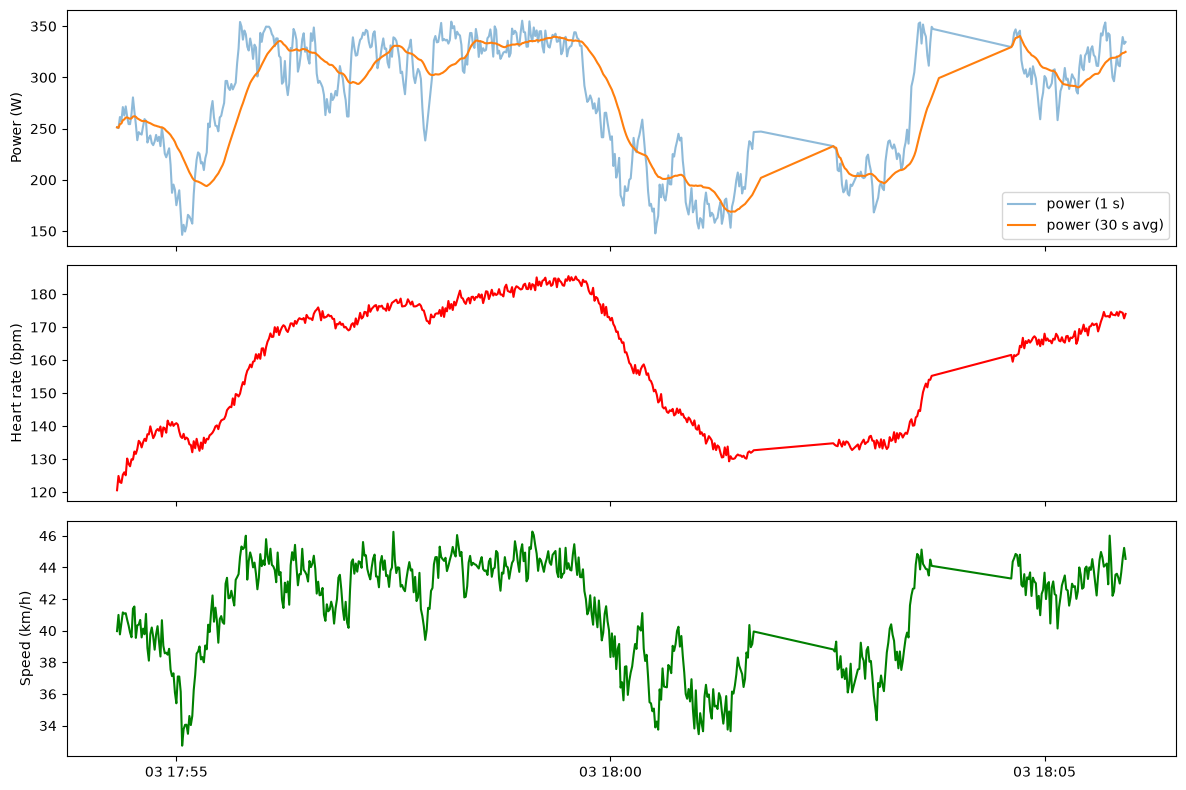

In [26]:
import os
os.makedirs("images", exist_ok=True)

fig, axes = plt.subplots(3, 1, figsize=(12,8), sharex=True)
axes[0].plot(df.index, df["power"], alpha=0.5, label="power (1 s)")
axes[0].plot(df.index, df["power_30s"], label="power (30 s avg)")
axes[0].set_ylabel("Power (W)")
axes[0].legend()
axes[1].plot(df.index, df["hr"], color="red")
axes[1].set_ylabel("Heart rate (bpm)")
axes[2].plot(df.index, df["speed"], color="green")
axes[2].set_ylabel("Speed (km/h)")
plt.tight_layout()
plt.savefig("images/timeseries.png", dpi=120)
plt.show()

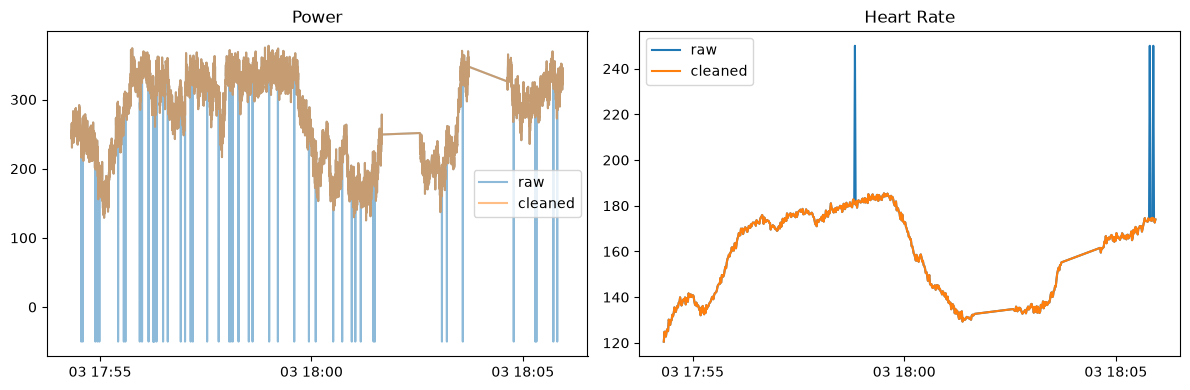

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(power_raw.index, power_raw["value"], alpha=0.5, label="raw")
axes[0].plot(power.index, power["value"], alpha=0.5, label="cleaned")
axes[0].set_title("Power")
axes[0].legend()
axes[1].plot(hr_raw.index, hr_raw["value"], label="raw")
axes[1].plot(hr.index, hr["value"], label="cleaned")
axes[1].set_title("Heart Rate")
axes[1].legend()
plt.tight_layout()
plt.savefig("images/cleaning.png", dpi=120)
plt.show()

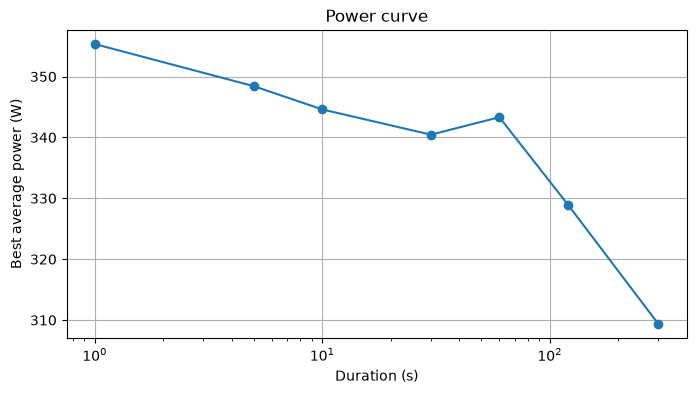

In [28]:
durations = [1, 5, 10, 30, 60, 120, 300]
best = [df["power"].rolling(f"{d}s").mean().max() for d in durations]

plt.figure(figsize=(8,4))
plt.plot(durations, best, marker="o")
plt.xscale("log")
plt.xlabel("Duration (s)")
plt.ylabel("Best average power (W)")
plt.title("Power curve")
plt.grid(True)
plt.savefig("images/power_curve.png", dpi=120)
plt.show()